<a href="https://colab.research.google.com/github/Manideep2k4/pest-detection-ip102/blob/main/yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1 - Install
!pip install ultralytics

# Step 2 - Import and check
from ultralytics import YOLO

# Step 3 - Load a pretrained model
model = YOLO('yolov8n.pt')

# Step 4 - Run it on a sample image (built-in test)
results = model.predict('https://ultralytics.com/images/bus.jpg', save=True)
print(results)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 76.5ms
Speed: 15.2ms preprocess, 76.5ms inference, 45.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign

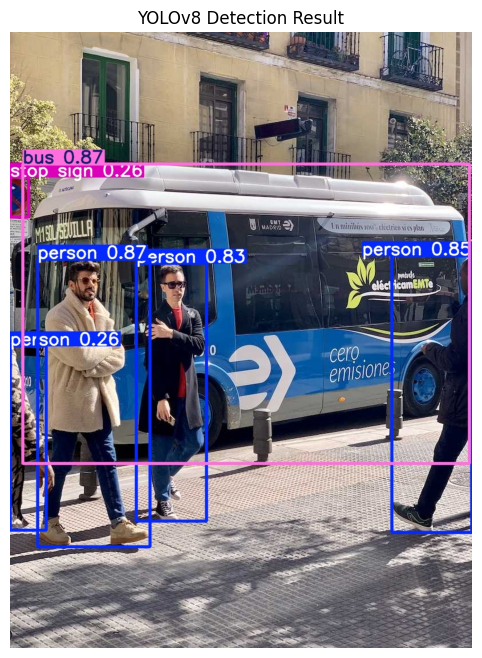

In [ ]:
# Cell 2 — Visualize the result
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/content/runs/detect/predict/bus.jpg')
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title('YOLOv8 Detection Result')
plt.show()

In [ ]:
# Cell 3 — Set up Kaggle directly
import os

# Replace with your NEW key after regenerating
os.environ['KAGGLE_USERNAME'] = 'manideeep2k4'
os.environ['KAGGLE_KEY'] = 'KGAT_29be8720cf1ef92e1344f9d5558b2e54'

# Make the kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Write the credentials file
import json
creds = {'username': os.environ['KAGGLE_USERNAME'], 'key': os.environ['KAGGLE_KEY']}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle configured successfully!")

Kaggle configured successfully!


In [ ]:
# Cell 4 — Download IP102 dataset
!kaggle datasets download -d rtlmhjbn/ip02-dataset
print("Download complete!")

Dataset URL: https://www.kaggle.com/datasets/rtlmhjbn/ip02-dataset
License(s): copyright-authors
100% 2.94G/2.94G [03:04<00:00, 17.1MB/s]

Download complete!


In [ ]:
import zipfile
import os
with zipfile.ZipFile('/content/ip02-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/IP102')

print("Extracted!")
print(os.listdir('/content/IP102'))

Extracted!
['val.txt', 'test.txt', 'classification', 'train.txt', 'classes.txt']


In [ ]:
# Cell 6 — Explore structure
import os

# Check what's inside classification
print("Inside classification:")
print(os.listdir('/content/IP102/classification'))

# Check one level deeper
first_folder = os.listdir('/content/IP102/classification')[0]
print(f"\nInside classification/{first_folder}:")
print(os.listdir(f'/content/IP102/classification/{first_folder}'))

In [ ]:
# Cell 7 — Understand the dataset
import os
from pathlib import Path

base = '/content/IP102/classification'

# Count images in each split
for split in ['train', 'val', 'test']:
    total = 0
    split_path = Path(base) / split
    for cls in os.listdir(split_path):
        total += len(os.listdir(split_path / cls))
    print(f"{split}: {total} images across {len(os.listdir(split_path))} classes")

# Read class names
with open('/content/IP102/classes.txt', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

print(f"\nTotal classes: {len(classes)}")
print(f"\nFirst 10 classes:")
for i, c in enumerate(classes[:10]):
    print(f"  {i}: {c}")

train: 45095 images across 102 classes
val: 7508 images across 102 classes
test: 22619 images across 102 classes

Total classes: 102

First 10 classes:
  0: 1  rice leaf roller
  1: 2  rice leaf caterpillar
  2: 3  paddy stem maggot
  3: 4  asiatic rice borer
  4: 5  yellow rice borer
  5: 6  rice gall midge
  6: 7  Rice Stemfly
  7: 8  brown plant hopper
  8: 9  white backed plant hopper
  9: 10 small brown plant hopper


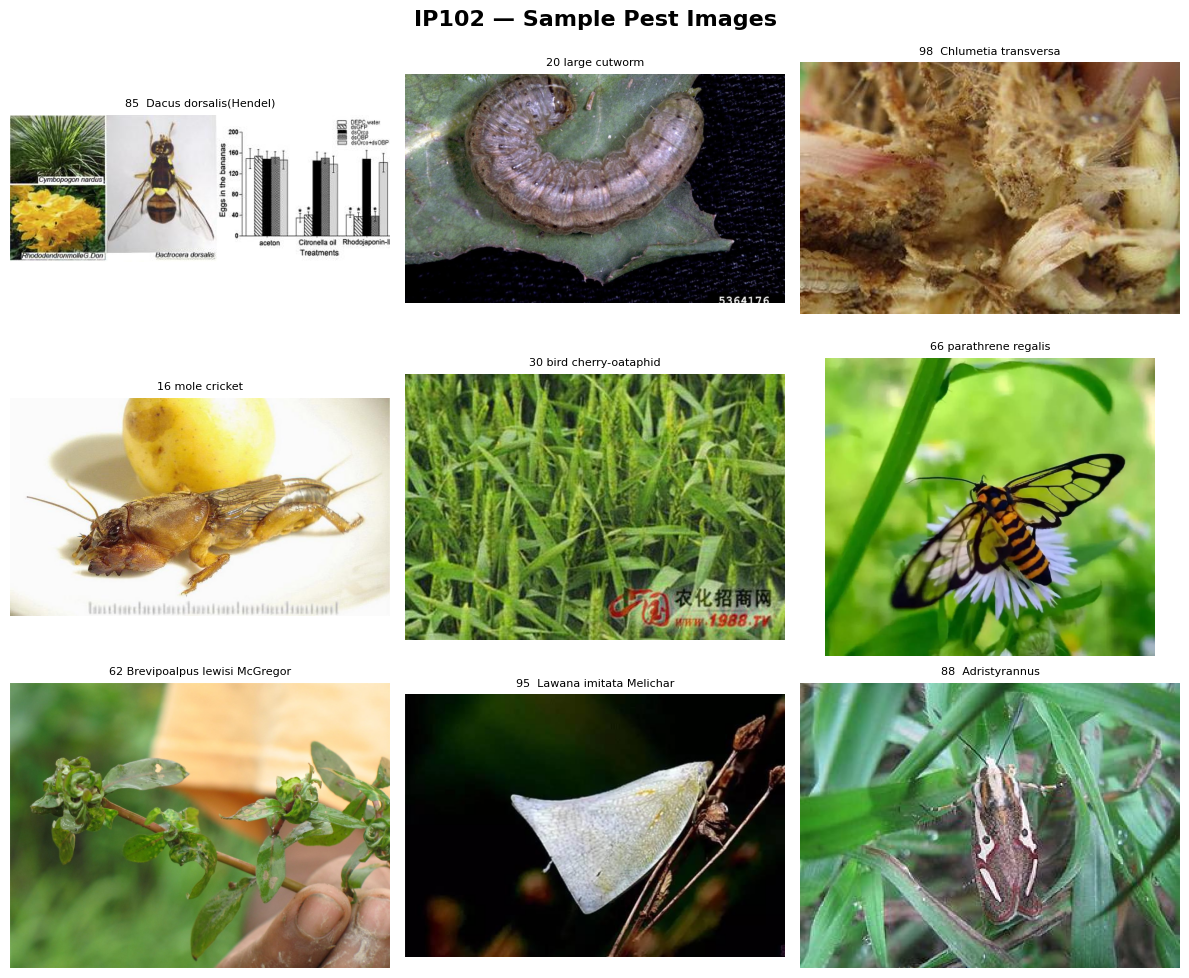

Saved as sample_pests.png


In [ ]:
# Cell 8 — Visualize sample images from different pest classes
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

base = '/content/IP102/classification/train'
classes_file = '/content/IP102/classes.txt'

with open(classes_file, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]

# Pick 9 random classes to visualize
sample_classes = random.sample(os.listdir(base), 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('IP102 — Sample Pest Images', fontsize=16, fontweight='bold')

for ax, cls_id in zip(axes.flatten(), sample_classes):
    cls_path = os.path.join(base, cls_id)
    img_file = random.choice(os.listdir(cls_path))
    img = mpimg.imread(os.path.join(cls_path, img_file))
    ax.imshow(img)
    ax.set_title(class_names[int(cls_id)], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_pests.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as sample_pests.png")

In [ ]:
# Cell 9 — Convert classification structure to YOLO detection format
import os
import shutil
from pathlib import Path

src_base = Path('/content/IP102/classification')
dst_base = Path('/content/IP102_YOLO')

# Create YOLO folder structure
for split in ['train', 'val', 'test']:
    (dst_base / 'images' / split).mkdir(parents=True, exist_ok=True)
    (dst_base / 'labels' / split).mkdir(parents=True, exist_ok=True)

# Convert — copy images and create label files
for split in ['train', 'val', 'test']:
    src_split = src_base / split
    img_count = 0
    for cls_id in os.listdir(src_split):
        cls_path = src_split / cls_id
        for img_file in os.listdir(cls_path):
            # Copy image
            src_img = cls_path / img_file
            dst_img = dst_base / 'images' / split / f"{cls_id}_{img_file}"
            shutil.copy2(src_img, dst_img)
            # Create YOLO label — full image bounding box
            # format: class_id cx cy width height (normalized)
            label_file = dst_base / 'labels' / split / f"{cls_id}_{img_file.rsplit('.', 1)[0]}.txt"
            with open(label_file, 'w') as f:
                f.write(f"{int(cls_id)} 0.5 0.5 1.0 1.0\n")
            img_count += 1
    print(f"{split}: {img_count} images converted")

print("\nDone! YOLO dataset ready.")

train: 45095 images converted
val: 7508 images converted
test: 22619 images converted

Done! YOLO dataset ready.


In [ ]:
# Cell 10 — Create dataset YAML config
import yaml
from pathlib import Path

# Read class names
with open('/content/IP102/classes.txt', 'r') as f:
    class_names = [line.strip() for line in f.readlines()]

data = {
    'path': '/content/IP102_YOLO',
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 102,
    'names': class_names
}

yaml_path = '/content/IP102_YOLO/ip102.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False, allow_unicode=True)

print("Dataset config created!")
print(f"\nConfig preview:")
print(f"  Classes: {data['nc']}")
print(f"  Train: {data['train']}")
print(f"  Val: {data['val']}")
print(f"  Test: {data['test']}")
print(f"\nFirst 5 class names:")
for i, name in enumerate(class_names[:5]):
    print(f"  {i}: {name}")

In [ ]:
# Cell 11 — Train YOLOv8 on IP102
from ultralytics import YOLO

# Load pretrained YOLOv8 small model
model = YOLO('yolov8s.pt')

# Train
results = model.train(
    data='/content/IP102_YOLO/ip102.yaml',
    epochs=50,
    imgsz=224,
    batch=64,
    name='ip102_pest_detector',
    pretrained=True,
    optimizer='AdamW',
    lr0=0.001,
    patience=10,
    workers=4,
    cache=True,
    device=0
)
print("Training complete!")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/IP102_YOLO/ip102.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ip102_pest_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

In [ ]:
# Cell 12 — Save model to Google Drive so you don't lose it
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/runs/detect/ip102_pest_detector/weights/best.pt',
            '/content/drive/MyDrive/pest_detector_best.pt')
print("Model saved to Google Drive!")